In [1]:
from datetime import datetime
import pickle
import os
from multiprocessing import Pool

import numpy as np
import pandas as pd
import lingam
from scipy.stats import kendalltau

import matplotlib.pyplot as plt

N_CORES = 4

np.random.seed(0)

## 仮実装
τ計算はキャッシュを持たせると多少早くなる。しかしPoolで並列化するとキャッシュの管理が要るかもしれないが、調べる必要がある。

In [2]:
import pandas as pd

import itertools
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import scale
from sklearn.utils import check_array, check_scalar

from lingam import DirectLiNGAM

np.random.seed(0)

class HighDimDirectLiNGAM(DirectLiNGAM):
    
    def __init__(self, max_in_degree=3, degree=4, cut_off_scaling=0.5, **kwargs):
        super().__init__(**kwargs)

        self._max_in_degree = check_scalar(max_in_degree, "max_in_degree", int, min_val=2, include_boundaries="neither")
        self._degree = check_scalar(degree, "degree", int, min_val=1)
    
        self._cut_off_scaling = check_scalar(cut_off_scaling, "cut_off_scaling", (int, float), min_val=0)
    
    def _calc_tau(self, k, pa, ch):
        return abs(np.mean((pa ** (k - 1)) * ch) * np.mean(pa ** 2) - np.mean(pa ** k) * np.mean(pa * ch))
    
    def _calc_tau_multi_c(self, pa, ch, k, cond_sets, an_sets):
        n = self._Y.shape[0]
        ret = np.empty(self._Y.shape[1])
        ret.fill(1e10)
        
        for z in range(len(cond_sets)):
            cond = cond_sets[z]
            # XXX: 元はsolveで方程式を解いている。X = solve(A, B)は A*X = BとなるXを求める。では、X=A^-1 @ Bか。
            # https://arma.sourceforge.net/docs.html#solve
            b = np.linalg.pinv(self._yty[np.ix_(cond, cond)]) @ self._yty[cond, pa]
            resid = (self._Y[:, [pa]] - self._Y[:, cond] @ b.reshape(len(cond), 1)).flatten()

            resid_k_1 = np.power(resid, k - 1)
            resid_var = np.mean(np.power(resid, 2))
            resid_k = np.mean(np.power(resid, k))
            
            for i in range(len(ch)):
                ret[ch[i]] = np.min([
                    ret[ch[i]],
                    abs((1.0 / n ) * np.dot(resid_k_1, self._Y[:, ch[i]]) * resid_var - resid_k * (1.0 / n) * np.dot(resid, self._Y[:, ch[i]]))
                ])
            
            for i in range(an_sets.shape[1]):
                ret[an_sets[z, i]] = np.min([
                    ret[an_sets[z, i]],
                    abs((1.0 / n) * np.dot(resid_k_1.T, self._Y[:, an_sets[z, i]]) * resid_var - resid_k * (1.0 / n) * np.dot(resid.T, self._Y[:, an_sets[z, i]]))
                ])
                
            return ret

    def _get_tau_multi(self, i, j, degree, last_root, condition_set, max_in_degree):
        j = list(set(j) - set([i]))
        p = self._Y.shape[1]
        prune_stat = np.array([1e5 for _ in range(p)])
        
        if last_root is None:
            prune_stat[j] = list(map(lambda j: self._calc_tau(degree, self._Y[:, i], self._Y[:, j]), j))
            #print("first step", i, last_root)
            return prune_stat
        
        size_of_set = min(max_in_degree, len(condition_set))
        
        if len(condition_set - set([last_root])) == 1:
            condition_sub_set = np.array([list(condition_set - set([last_root]))]).reshape(1, 1)
        else:
            condition_sub_set = list(itertools.combinations(list(condition_set - set([last_root])), size_of_set - 1))
            condition_sub_set = np.array([list(e) for e in condition_sub_set])
        
        an_sets = np.array(list(map(lambda x: list(condition_set - set(x)), condition_sub_set)))
        if len(an_sets) == 1 and an_sets.shape[1] > 0:
            an_sets = an_sets.T
        
        if len(condition_sub_set) == 1 and len(condition_sub_set) == 0:
            condition_sub_set = np.array([last_root])
        else:
            condition_sub_set = np.concatenate([np.full(len(condition_sub_set), last_root).reshape(-1, 1), condition_sub_set], axis=1).astype(int)
        
        # XXX: 元コードで1を引くのはゼロ始まりということではないか？set系はベクトルだから全要素から引くのだろう。(condition_sub_setとか実際は1要素のベクトルにしからならないのでは？)
        #print(condition_sub_set, i, last_root)
        prune_stat = self._calc_tau_multi_c(i, j, degree, condition_sub_set, an_sets)
        return prune_stat
        
    def fit(self, Y):
        self._Y = check_array(Y)
        
        # cov
        self._yty = self._Y.T @ self._Y
        
        cut_off = 0
        
        ordered = []
        p = self._Y.shape[1]
        
        unordered = list(range(p))
        
        prune_stats = np.full((p, p), 1e5)
        np.fill_diagonal(prune_stats, 0)
        
        while len(unordered) > 1:
            output_cond_set = []
            output_tau_min = []
            for i in unordered:
                cond_set = set.intersection(set(ordered), set(np.argwhere(prune_stats[i] > cut_off).flatten()))
                cond_set = set.union(cond_set, set(ordered[-1:] if len(ordered) > 0 else set()))
            
                last_root = ordered[-1] if len(ordered) > 0 else None
                tau_min = self._get_tau_multi(i, unordered, self._degree, last_root, cond_set, self._max_in_degree)
                
                output_cond_set.append(cond_set)
                output_tau_min.append(tau_min)
            output_tau = np.array(output_tau_min)
            
            prune_stats[unordered, :] = np.min([prune_stats[unordered, :], output_tau], axis=0)
            np.fill_diagonal(prune_stats, 0)
            
            output_tau_stats = np.max(prune_stats[np.ix_(unordered, unordered)], axis=1)
            
            root = unordered[np.argmin(output_tau_stats)]
            
            cut_off = max(cut_off, min(output_tau_stats) * self._cut_off_scaling)
            
            ordered.append(root)
            unordered.remove(root)
        
        self._causal_order = np.array(ordered + unordered)
        return self

## DAGと誤差変数の生成

In [3]:
# 通常のランダム生成
def make_dag_and_errors(n_nodes, sample_size, J=3, weight=0.5):
    dag = np.zeros((n_nodes, n_nodes))
    errors = None
    
    # For each node v
    for v in range(n_nodes):        
        #  select the number of parents
        num_pa = np.random.choice(np.arange(min(n_nodes, J)))

        if v - 1 >= 0:
            # We include edge (v − 1, v) to ensure that the ordering is unique
            dag[v, v - 1] = np.random.choice([-1, 1]) * np.random.uniform(weight, 1)

        # The remaining parents are selected uniformly from [v − 2]
        candidates = np.arange(v - 1)
        if len(candidates) == 0:
            continue

        # num_paは最低3あるが、例えば2列目の変数の候補は[0]しかない。(1は順序を一意に保つために使う)
        # そのためlen(candidate)との大小関係もチェックが要る。
        pa = np.random.choice(candidates, size=min(num_pa, len(candidates)), replace=False)

        # the corresponding edge weights are set to +-1/5
        dag[v, pa] = np.random.choice([-1/5, 1/5], size=len(pa))

    # The n error terms for variable v are generated by selecting σv ∼ unif(.8, 1) drawing εvi ∼ σvunif(−√3,√3).
    v = np.random.uniform(0.8, 1, size=n_nodes)
    errors = v * np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(sample_size, n_nodes))

    return dag, errors

# ハブ付き
def make_dag_and_errors_hub(n_nodes, sample_size, J=2):
    # HubGraph
    dag, _ = make_dag_and_errors(n_nodes, sample_size, J=J, weight=0.65)

    # add hubs
    # 非hubノードはいずれかのハブからのエッジを受けること。対角直下は決まっているので手をださないこと。
    for v in np.arange(3, n_nodes):
        # ハブの選択と係数の作成
        coefs = np.zeros(3)
        
        if v == 3:
            # 変数3のみ特別処理。変数2との接続は強制なのでそれ以外から選ぶ。
            index = np.random.choice([0, 1])
        else:
            index = np.random.choice([0, 1, 2])
        
        coefs[index] = np.random.choice([-1/5, 1/5])

        # すでに係数が設定してあれば、そちらを優先する。coefはdag側が0である部分のみ非ゼロになる。
        filter_ = ~np.isclose(dag[v, :3], 0)
        coefs[filter_] = 0
        
        # フィルタしているので足して設定する
        dag[v, :3] += coefs

    # disturbances
    v = np.random.uniform(0.8, 1, size=n_nodes)
    errors = v * np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(sample_size, n_nodes))
    
    return dag, errors

### ランダム生成の例
隣接行列における対角の下が強め、ランダムなエッジは小さめになる。因果順序を一意にするために対角の下に必ず値を持つ。対角下が強め、その他の係数は±0.2。

,0,1,2,3,4,5,6,7
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.801382,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,-0.200000,0.822947,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,-0.200000,0.200000,-0.981831,0.000000,0.000000,0.000000,0.000000,0.000000
4,-0.200000,0.000000,0.200000,-0.696392,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.684121,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,-0.736804,0.000000,0.000000
7,0.000000,0.000000,-0.200000,0.000000,-0.200000,0.000000,0.819961,0.000000


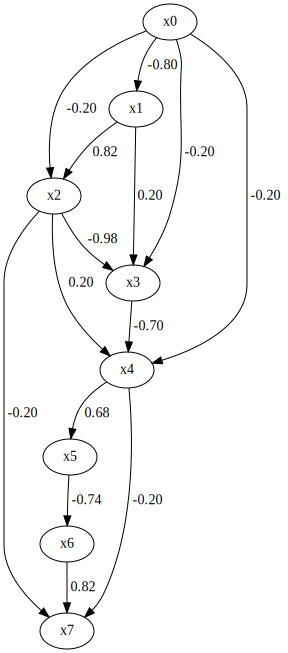

In [4]:
dag, errors = make_dag_and_errors(8, 1000)
display(pd.DataFrame(dag).style.background_gradient(vmin=-1, vmax=1))

lingam.utils.make_dot(dag)

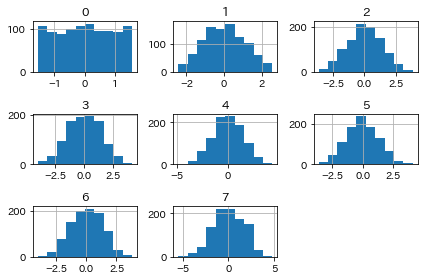

In [5]:
X = errors @ np.linalg.pinv(np.eye(len(dag)) - dag).T
pd.DataFrame(X).hist()
plt.tight_layout()
plt.show()

### ハブつきランダム生成の例

ノード0, 1, 2がハブとなり多くの変数の親となるため、0, 1, 2列は非ゼロの値がいくつか格納される。

In [6]:
dag, errors = make_dag_and_errors_hub(8, 1000)
pd.DataFrame(dag).style.background_gradient(vmin=-1, vmax=1)

,0,1,2,3,4,5,6,7
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.992674,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.200000,0.758404,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,-0.200000,0.994157,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.200000,0.000000,-0.200000,-0.761634,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.200000,-0.200000,0.000000,-0.805072,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.200000,0.000000,0.000000,0.900371,0.000000,0.000000
7,-0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.740583,0.000000


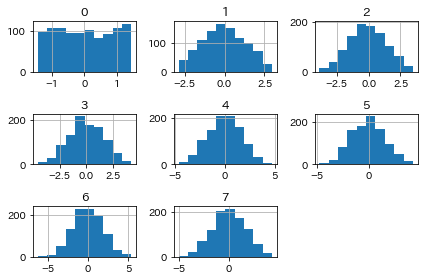

In [7]:
X = errors @ np.linalg.pinv(np.eye(len(dag)) - dag).T
pd.DataFrame(X).hist()
plt.tight_layout()
plt.show()

## 検証関数
実行環境にあったループ数とコア数を設定するとよい。

In [8]:
def n_list_func_impl(p):
    return [10 * p, 50 * p]

def test_impl(args):
    p, n, i, seed, disable_direct, make_func = args
    
    np.random.seed(seed)
    
    true_order = np.arange(p)

    dag, errors = make_func(p, n)
    X = (np.linalg.pinv(np.eye(p) - dag) @ errors.T).T

    # evals high_im
    high_d_start = datetime.now()

    # XXX:
    #high_d_model = lingam.HighDimDirectLiNGAM()
    #high_d_model = lingam.DirectLiNGAM()
    high_d_model = HighDimDirectLiNGAM()
    high_d_model.fit(X)

    elapse_high_d = (datetime.now() - high_d_start).total_seconds()

    eval_high_d = kendalltau(high_d_model.causal_order_, true_order).statistic

    # evals normal
    if disable_direct:
        eval_normal = None
        elapse_normal = None
    else:
        normal_start = datetime.now()
        
        normal_model = lingam.DirectLiNGAM()
        normal_model.fit(X)
        
        elapse_normal = (datetime.now() - normal_start).total_seconds()

        eval_normal = kendalltau(normal_model.causal_order_, true_order).statistic
        
    print(f"\r{i:8d}", end="")

    return i, eval_high_d, elapse_high_d, eval_normal, elapse_normal
            
def run_test(p_list=None, n_list_func=None, loop_num=500, make_func=None, disable_direct=False, n_cores=24, test_impl=test_impl):
    if p_list is None:
        p_list = np.arange(5, 25, 5, dtype=int)

    if n_list_func is None:
        n_list_func = n_list_func_impl

    if make_func is None:
        make_func = make_dag_and_errors
    
    results = {}
    
    for p in p_list:
        for n in n_list_func(p):
            print(f"+p={p:4d}, n={n:4d}")
            
            start = datetime.now()
            
            # テスト実行の引数を辞書に詰め込む
            seeds = np.random.randint(0, high=0xFFFFFFFF, size=loop_num)
            args = {(p, n, i, seed, disable_direct, make_func) for i, seed in enumerate(seeds)}
            
            # マルチプロセスの有効無効
            if n_cores > 0:
                with Pool(n_cores) as pool:
                    result = pool.map(test_impl, args)
            else:
                result = []
                for arg in args:
                    result.append(test_impl(arg))
                
            result = sorted(result, key=lambda e: e[0])
            indices, eval_high_d, elapse_high_d, eval_normal, elapse_normal = np.array(result).T
            
            results[(n, p)] = {
                "high_d": eval_high_d,
                "normal": eval_normal,
                "elapse_high_d": elapse_high_d,
                "elapse_normal": elapse_normal,
            }
            
            elapse = (datetime.now() - start).total_seconds()
            
            print(f"\r-p={p:4d}, n={n:4d}, elapse={elapse:.2f}sec")

    max_p = max(p_list)
    max_n = max(n_list_func(max_p))
    fname = datetime.now().strftime('%Y%m%d%H%M%S') + f"_{max_p}_{max_n}_{loop_num}.bin"

    with open(fname, "wb") as f:
        pickle.dump(results, f)
    print("saved:", fname)
        
    return results

## 低次元時の検証

In [9]:
if True:
    results = run_test(
        # XXX:
        #loop_num=500,
        loop_num=32,
        n_cores=N_CORES,
        p_list = np.arange(5, 25, 5, dtype=int),
        n_list_func=n_list_func_impl
    )
else:
    # run_test後に得られるpickleを読み込む場合はこちら
    with open("20240627141751_20_1000_8.bin", "rb") as f:
        results = pickle.load(f)

+p=   5, n=  50
-p=   5, n=  50, elapse=0.24sec
+p=   5, n= 250
-p=   5, n= 250, elapse=0.24sec
+p=  10, n= 100
-p=  10, n= 100, elapse=1.24sec
+p=  10, n= 500
-p=  10, n= 500, elapse=1.39sec
+p=  15, n= 150
-p=  15, n= 150, elapse=4.11sec
+p=  15, n= 750
-p=  15, n= 750, elapse=4.96sec
+p=  20, n= 200
-p=  20, n= 200, elapse=12.48sec
+p=  20, n=1000
-p=  20, n=1000, elapse=18.23sec
saved: 20240701222740_20_1000_32.bin


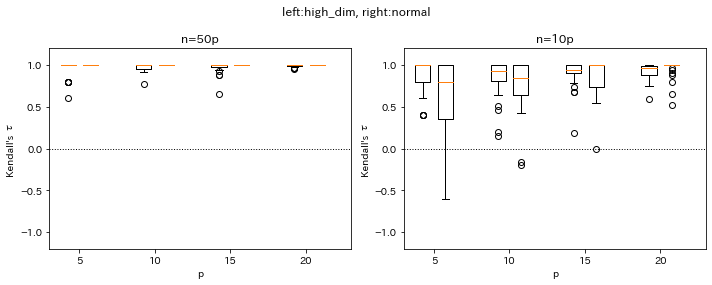

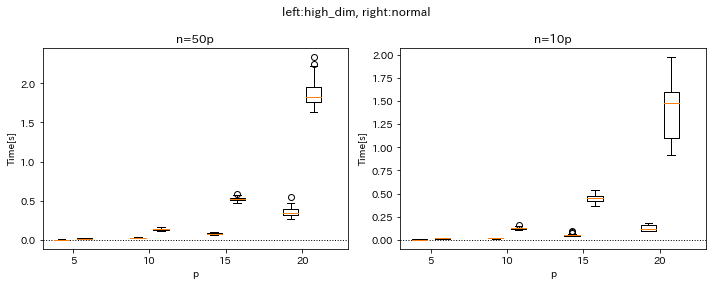

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for (n, p), evals in results.items():
    ax = axes[0] if n / p == 50.0 else axes[1]
    
    ax.boxplot(
        evals["high_d"],
        positions=[p - 0.75],
        widths=[1],
    )

    ax.boxplot(
        evals["normal"],
        positions=[p + 0.75],
        widths=[1],
    )
    
axes[0].set_title("n=50p")
axes[1].set_title("n=10p")
axes[0].set_ylim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)
axes[0].set_xlim(3, 23)
axes[1].set_xlim(3, 23)
axes[0].axhline(0, color="black", lw=1, ls="dotted")
axes[1].axhline(0, color="black", lw=1, ls="dotted")
axes[0].set_xticks([5, 10, 15, 20])
axes[1].set_xticks([5, 10, 15, 20])
axes[0].set_xticklabels([5, 10, 15, 20])
axes[1].set_xticklabels([5, 10, 15, 20])
axes[0].set_xlabel("p")
axes[1].set_xlabel("p")
axes[0].set_ylabel("Kendall's τ")
axes[1].set_ylabel("Kendall's τ")
plt.suptitle("left:high_dim, right:normal")
plt.tight_layout()
plt.show()


# 時間
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for (n, p), evals in results.items():
    ax = axes[0] if n / p == 50.0 else axes[1]
    
    ax.boxplot(
        evals["elapse_high_d"],
        positions=[p - 0.75],
        widths=[1],
    )

    ax.boxplot(
        evals["elapse_normal"],
        positions=[p + 0.75],
        widths=[1],
    )
    
axes[0].set_title("n=50p")
axes[1].set_title("n=10p")
axes[0].set_xlim(3, 23)
axes[1].set_xlim(3, 23)
axes[0].axhline(0, color="black", lw=1, ls="dotted")
axes[1].axhline(0, color="black", lw=1, ls="dotted")
axes[0].set_xticks([5, 10, 15, 20])
axes[1].set_xticks([5, 10, 15, 20])
axes[0].set_xticklabels([5, 10, 15, 20])
axes[1].set_xticklabels([5, 10, 15, 20])
axes[0].set_xlabel("p")
axes[1].set_xlabel("p")
axes[0].set_ylabel("Time[s]")
axes[1].set_ylabel("Time[s]")
plt.suptitle("left:high_dim, right:normal")
plt.tight_layout()
plt.show()

## 高次元時の検証(ランダム生成)
p>nになるとDirectLiNGAMのLassoLarsICがエラーを出す。

In [11]:
p_list = [50]
n_list_func = lambda p: [int((3 / 4) * p)]

if True:
    results2 = run_test(
        p_list=p_list,
        n_list_func=n_list_func,
        loop_num=32,
        make_func=make_dag_and_errors,
        disable_direct=True,
        n_cores=N_CORES,
    )
else:
    with open("20240627193115_50_37_8.bin", "rb") as f:
        results2 = pickle.load(f)

+p=  50, n=  37
-p=  50, n=  37, elapse=12.36sec
saved: 20240701222753_50_37_32.bin


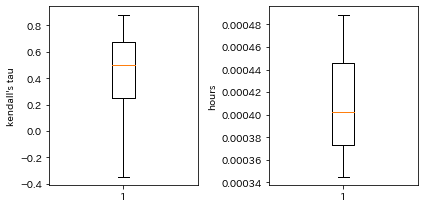

In [12]:
# 精度、時間

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].boxplot(results2[(37, 50)]["high_d"])
axes[0].set_ylabel("kendall's tau")
axes[1].boxplot(results2[(37, 50)]["elapse_high_d"] / 3600)
axes[1].set_ylabel("hours")
plt.tight_layout()
plt.show()

## 高次元時の検証(ハブ付き)

In [13]:
p_list = [50]
n_list_func = lambda p: [int((3 / 4) * p)]

if True:
    results3 = run_test(
        p_list=p_list,
        n_list_func=n_list_func,
        loop_num=32,
        make_func=make_dag_and_errors_hub,
        disable_direct=True,
        n_cores=N_CORES,
    )
else:
    with open("20240628003454_50_37_8.bin", "rb") as f:
        results3 = pickle.load(f)

+p=  50, n=  37
-p=  50, n=  37, elapse=12.24sec
saved: 20240701222806_50_37_32.bin


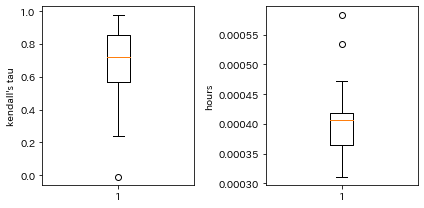

In [14]:
# 精度、時間

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].boxplot(results3[(37, 50)]["high_d"])
axes[0].set_ylabel("kendall's tau")
axes[1].boxplot(results3[(37, 50)]["elapse_high_d"] / 3600)
axes[1].set_ylabel("hours")
plt.tight_layout()
plt.show()

## 実行時間の予測

log(y) = a * x + b で線形回帰して予測した。データは4点。
x =  [ 5 10 15 20]
y =  [0.00487466 0.02798991 0.08290206 0.35817878]


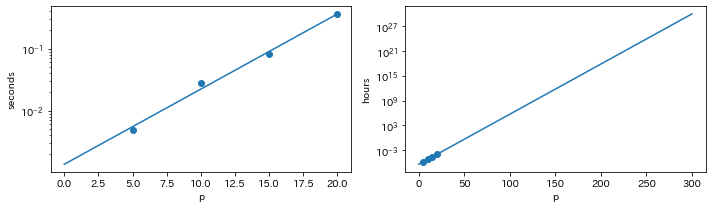

1回実行するのに…
p=10,n=50*pで 0.000006 時間
p=20,n=50*pで 0.000101 時間
p=30,n=50*pで 0.001660 時間
p=40,n=50*pで 0.027172 時間
p=50,n=50*pで 0.444758 時間


In [15]:
ts = [results[k]["elapse_high_d"] for k in [(250, 5), (500, 10), (750, 15), (1000, 20)]]

x = np.array([5, 10, 15, 20]).reshape(-1, 1)
y = np.mean(ts, axis=1)

print("log(y) = a * x + b で線形回帰して予測した。データは4点。")
print("x = ", x.flatten())
print("y = ", np.mean(ts, axis=1).flatten())

from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=True)
model.fit(x, np.log(y))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

ax = axes[0]
x_range = np.linspace(0, 20, 100).reshape(-1, 1)
y_hat = np.exp(model.predict(x_range))
ax.plot(x_range, y_hat)
ax.scatter(x, y)
ax.set_yscale("log")
ax.set_ylabel("seconds")
ax.set_xlabel("p")

ax = axes[1]
x_range = np.linspace(0, 300, 10).reshape(-1, 1)
y_hat = np.exp(model.predict(x_range))
ax.plot(x_range, y_hat/3600)
ax.scatter(x, y/3600)
ax.set_yscale("log")
ax.set_ylabel("hours")
ax.set_xlabel("p")

plt.tight_layout()
plt.show()

print("1回実行するのに…")
for i in [10, 20, 30, 40, 50]:
    print(f"p={i},n=50*pで {(np.exp(model.predict([[i]]))/3600)[0]:f} 時間")

## その他検証用
後で消す予定。

In [16]:
import subprocess

# saving script
r_script = """
library(highDLingam)
library(doParallel)

args <- commandArgs(trailingOnly = T)

name <- sprintf("temp/temp_%05d.csv", as.numeric(args))
X <- read.csv(name)

result <- findGraphMulti(as.matrix(X), degree=4)
cat("top_order=", result$topOrder, "\n")
"""

with open("script.r", "w") as f:
    f.write(r_script)
    
if not os.path.isdir("temp"):
    os.mkdir("temp")

def test_impl_original(args):
    p, n, i, seed, disable_direct, make_func = args
    
    np.random.seed(seed)
    
    true_order = np.arange(p)

    dag, errors = make_func(p, n)
    X = (np.linalg.pinv(np.eye(p) - dag) @ errors.T).T
    pd.DataFrame(X).to_csv(f"temp/temp_{i:05d}.csv", index=None)
    
    # evals high_im
    start = datetime.now()

    # サブプロセスで実行して標準出力をキャプチャ
    result = subprocess.run(["Rscript", "script.r", f"{i}"], capture_output=True)

    elapse = (datetime.now() - start).total_seconds()
    
    order = [line for line in result.stdout.decode().split("\n") if line.startswith("top_order=")][0]
    order = [int(e) for e in order.split("= ")[1].split(" ")[:-1]]
    
    eval_val = kendalltau(order, true_order).statistic

    print(f"\r{i:8d}", end="")

    return i, eval_val, elapse, None, None

In [17]:
# 低次元
results4 = run_test(
    loop_num=32,
    n_cores=N_CORES,
    p_list = np.arange(5, 25, 5, dtype=int),
    n_list_func=n_list_func_impl,
    test_impl=test_impl_original,
)

+p=   5, n=  50
-p=   5, n=  50, elapse=3.83sec
+p=   5, n= 250
-p=   5, n= 250, elapse=3.76sec
+p=  10, n= 100
-p=  10, n= 100, elapse=4.46sec
+p=  10, n= 500
-p=  10, n= 500, elapse=4.81sec
+p=  15, n= 150
-p=  15, n= 150, elapse=5.67sec
+p=  15, n= 750
-p=  15, n= 750, elapse=6.69sec
+p=  20, n= 200
-p=  20, n= 200, elapse=7.59sec
+p=  20, n=1000
-p=  20, n=1000, elapse=9.96sec
saved: 20240701222853_20_1000_32.bin


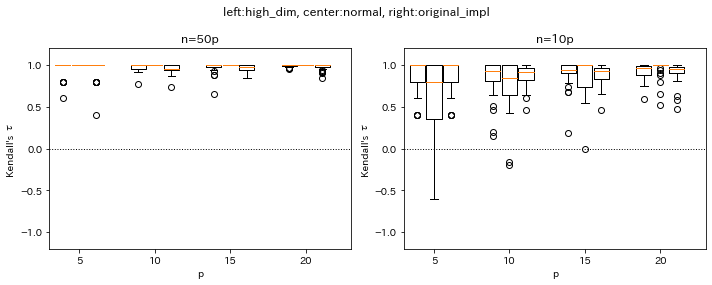

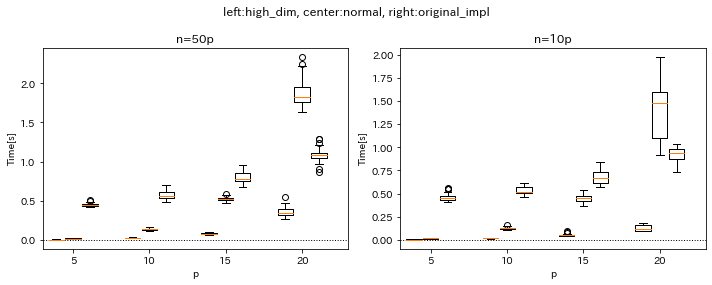

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ((n, p), evals), (_, evals_orig) in zip(results.items(), results4.items()):
    ax = axes[0] if n / p == 50.0 else axes[1]
    
    ax.boxplot(
        evals["high_d"],
        positions=[p - 1.1],
        widths=[1],
    )

    ax.boxplot(
        evals["normal"],
        positions=[p + 0],
        widths=[1],
    )
    
    ax.boxplot(
        evals_orig["high_d"],
        positions=[p + 1.1],
        widths=[1],
    )
    
axes[0].set_title("n=50p")
axes[1].set_title("n=10p")
axes[0].set_ylim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)
axes[0].set_xlim(3, 23)
axes[1].set_xlim(3, 23)
axes[0].axhline(0, color="black", lw=1, ls="dotted")
axes[1].axhline(0, color="black", lw=1, ls="dotted")
axes[0].set_xticks([5, 10, 15, 20])
axes[1].set_xticks([5, 10, 15, 20])
axes[0].set_xticklabels([5, 10, 15, 20])
axes[1].set_xticklabels([5, 10, 15, 20])
axes[0].set_xlabel("p")
axes[1].set_xlabel("p")
axes[0].set_ylabel("Kendall's τ")
axes[1].set_ylabel("Kendall's τ")
plt.suptitle("left:high_dim, center:normal, right:original_impl")
plt.tight_layout()
plt.show()


# 時間
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ((n, p), evals), (_, evals_orig) in zip(results.items(), results4.items()):
    ax = axes[0] if n / p == 50.0 else axes[1]
    
    ax.boxplot(
        evals["elapse_high_d"],
        positions=[p - 1.1],
        widths=[1],
    )

    ax.boxplot(
        evals["elapse_normal"],
        positions=[p + 0],
        widths=[1],
    )
    
    ax.boxplot(
        evals_orig["elapse_high_d"],
        positions=[p + 1.1],
        widths=[1],
    )
    
axes[0].set_title("n=50p")
axes[1].set_title("n=10p")
axes[0].set_xlim(3, 23)
axes[1].set_xlim(3, 23)
axes[0].axhline(0, color="black", lw=1, ls="dotted")
axes[1].axhline(0, color="black", lw=1, ls="dotted")
axes[0].set_xticks([5, 10, 15, 20])
axes[1].set_xticks([5, 10, 15, 20])
axes[0].set_xticklabels([5, 10, 15, 20])
axes[1].set_xticklabels([5, 10, 15, 20])
axes[0].set_xlabel("p")
axes[1].set_xlabel("p")
axes[0].set_ylabel("Time[s]")
axes[1].set_ylabel("Time[s]")
plt.suptitle("left:high_dim, center:normal, right:original_impl")
plt.tight_layout()
plt.show()

In [19]:
# 高次元
p_list = [50]
n_list_func = lambda p: [int((3 / 4) * p)]

# ハブなし
results5 = run_test(
    p_list=p_list,
    n_list_func=n_list_func,
    loop_num=32,
    make_func=make_dag_and_errors,
    disable_direct=True,
    n_cores=N_CORES,
    test_impl=test_impl_original
)

# ハブ付き
results6 = run_test(
    p_list=p_list,
    n_list_func=n_list_func,
    loop_num=32,
    make_func=make_dag_and_errors_hub,
    disable_direct=True,
    n_cores=N_CORES,
    test_impl=test_impl_original
)

+p=  50, n=  37
-p=  50, n=  37, elapse=16.34sec
saved: 20240701222911_50_37_32.bin
+p=  50, n=  37
-p=  50, n=  37, elapse=20.28sec
saved: 20240701222931_50_37_32.bin


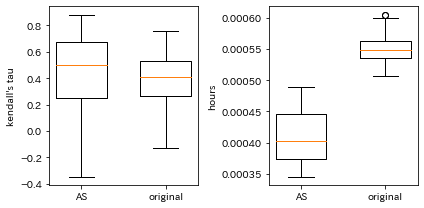

In [20]:
# 精度、時間

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].boxplot(results2[(37, 50)]["high_d"], positions=[-1], widths=[1.2])
axes[0].boxplot(results5[(37, 50)]["high_d"], positions=[1], widths=[1.2])
axes[0].set_ylabel("kendall's tau")
axes[0].set_xticks([-1, 1])
axes[0].set_xticklabels(["AS", "original"])

axes[1].boxplot(results2[(37, 50)]["elapse_high_d"] / 3600, positions=[-1], widths=[1.2])
axes[1].boxplot(results5[(37, 50)]["elapse_high_d"] / 3600, positions=[1], widths=[1.2])
axes[1].set_ylabel("hours")
axes[1].set_xticks([-1, 1])
axes[1].set_xticklabels(["AS", "original"])

plt.tight_layout()
plt.show()

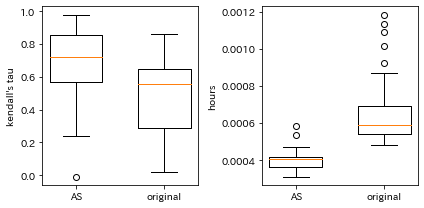

In [21]:
# 精度、時間

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].boxplot(results3[(37, 50)]["high_d"], positions=[-1], widths=[1.2])
axes[0].boxplot(results6[(37, 50)]["high_d"], positions=[1], widths=[1.2])
axes[0].set_ylabel("kendall's tau")
axes[0].set_xticks([-1, 1])
axes[0].set_xticklabels(["AS", "original"])

axes[1].boxplot(results3[(37, 50)]["elapse_high_d"] / 3600, positions=[-1], widths=[1.2])
axes[1].boxplot(results6[(37, 50)]["elapse_high_d"] / 3600, positions=[1], widths=[1.2])
axes[1].set_ylabel("hours")
axes[1].set_xticks([-1, 1])
axes[1].set_xticklabels(["AS", "original"])

plt.tight_layout()
plt.show()